In [1]:
import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader, random_split

import torchvision
from torchvision.transforms import v2

import sys
import os
import matplotlib.pyplot as plt
import numpy as np

import json
from tqdm import tqdm
from PIL import Image

plt.style.use('dark_background')

In [2]:
# Определяем устройство для работы
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

# Задача классификации

In [8]:
class MNISTDataset(Dataset):
    def __init__(self, path, transform=None):
        self.path = path
        self.transform = transform

        self.len_dataset = 0
        self.data_list = []

        for path_dir, dir_list, file_list in os.walk(path):
            if path_dir == path:
                self.classes = dir_list
                self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.classes)}
                continue

            if sys.platform == 'linux':
                cls = path_dir.split('/')[-1]
            elif sys.platform == 'win32':
                cls = path_dir.split('\\')[-1]

            for name_file in file_list:
                file_path = os.path.join(path_dir, name_file)
                self.data_list.append((file_path, self.class_to_idx[cls]))

            self.len_dataset += len(file_list)

    def __len__(self):
        return self.len_dataset

    def __getitem__(self, index):
        file_path, target = self.data_list[index]
        sample = np.array(Image.open(file_path))

        if self.transform is not None:
            sample = self.transform(sample)

        return sample, target

In [9]:
# Преобразования для изображения
transform = v2.Compose(
    [
        v2.ToImage(),
        v2.ToDtype(torch.float32, scale=True),
        v2.Normalize(mean=(0.5,), std=(0.5,))
    ]
)

In [10]:
# Создание датасетов
train_data = MNISTDataset('./drive/MyDrive/Colab_Notebooks/content/mnist/training', transform=transform) if 'google.colab' in sys.modules \
    else MNISTDataset('/Users/SashaCurry/PyCharmMiscProject/content/mnist/training', transform=transform)
test_data = MNISTDataset('./drive/MyDrive/Colab_Notebooks/content/mnist/training', transform=transform) if 'google.colab' in sys.modules \
    else MNISTDataset('/Users/SashaCurry/PyCharmMiscProject/content/mnist/training', transform=transform)

In [12]:
train_data, val_data = random_split(train_data, [0.7, 0.3])

In [13]:
# Создание загрузчиков
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
val_loader = DataLoader(val_data, batch_size=64, shuffle=False)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)


## Создание модели

In [16]:
class MyModel(nn.Module):
    def __init__(self, input, output):
        super().__init__()
        self.layer_1 = nn.Linear(input, 128)
        self.layer_2 = nn.Linear(128, output)
        self.activation = nn.ReLU()

    def forward(self, x):
        x = self.layer_1(x)
        x = self.activation(x)
        out = self.layer_2(x)
        return out

model = MyModel(784, 10).to(device)

In [17]:
# Проверяем правильность модели
input = torch.rand([16, 784], dtype=torch.float32).to(device)

out = model(input)
print(out.shape)

torch.Size([16, 10])


In [18]:
# Выбор фунцкии потерь и оптимизатор ГС
loss_model = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

## Тренировка модели

In [ ]:
# Цикл обучения
    # Тренировка модели
        # Данные
        # Прямой проход + расчет ошибки модели
        # Обратный проход
        # Шаг оптимизации
    # Расчет значения метрики
    # Сохранение значения функции потерь и метрики

    # Проверка модели (валидация)
        # Данные
        # Прямой проход + расчет ошибки модели
    # Расчет значения метрики
    # Сохранение значения функции потерь и метрики

In [31]:
EPOCHS = 50
train_loss = []
train_acc = []
val_loss = []
val_acc = []

# Цикл обучения
for epoch in range(EPOCHS):
    # Тренировка модели
    running_train_loss = []
    mean_train_loss = 0
    train_loop = tqdm(train_loader, leave=False) # создание progress bar
    true_answer = 0

    model.train()
    for x, targets in train_loop:
        # Данные
        # (batch_size, 1, 28, 28) -> (batch_size, 784)
        x = x.reshape(-1, 28*28).to(device)
        # (batch_size, int) -> (batch_size, 10), dtype=float32
        targets = targets.reshape(-1).to(torch.int32)
        targets = torch.eye(10)[targets].to(device)

        # Прямой проход + расчет ошибки модели
        pred = model(x)
        loss = loss_model(pred, targets)

        # Обратный проход
        optimizer.zero_grad()
        loss.backward()
        # Шаг оптимизации
        optimizer.step()

        running_train_loss.append(loss.item())
        mean_train_loss = sum(running_train_loss) / len(running_train_loss)

        true_answer += (pred.argmax(dim=1) == targets.argmax(dim=1)).sum().item()

        train_loop.set_description(f'Epoch [{epoch+1}/{EPOCHS}], train_loss={mean_train_loss:.4f}')

    # Расчет значения метрики
    running_train_acc = true_answer / len(train_data)

    # Сохранение значения функции потерь и метрики
    train_loss.append(mean_train_loss)
    train_acc.append(running_train_acc)

    # Проверка модели (валидация)
    model.eval()
    with torch.no_grad():
        running_val_loss = []
        true_answer = 0
        for x, targets in val_loader:
            # Данные
            # (batch_size, 1, 28, 28) -> (batch_size, 784)
            x = x.reshape(-1, 28*28).to(device)
            # (batch_size, int) -> (batch_size, 10), dtype=float32
            targets = targets.reshape(-1).to(torch.int32)
            targets = torch.eye(10)[targets].to(device)

            # Прямой проход + расчет ошибки модели
            pred = model(x)
            loss = loss_model(pred, targets)

            running_val_loss.append(loss.item())
            mean_val_loss = sum(running_val_loss) / len(running_val_loss)

            true_answer += (pred.argmax(dim=1) == targets.argmax(dim=1)).sum().item()

        # Расчет значения метрики
        running_val_acc = true_answer / len(val_data)

        # Сохранение значения функции потерь и метрики
        val_loss.append(mean_val_loss)
        val_acc.append(running_val_acc))

        print(f'Epoch [{epoch+1}/{EPOCHS}]: train_loss={mean_train_loss:.4f}, train_acc={running_train_acc:.4f}, val_loss={mean_val_loss:.4f}, val_acc={running_val_acc:.4f}')

Epoch [0/50]: train_loss=0.4258, train_acc=0.8779, val_loss=0.3266, val_acc=0.9030


Epoch [1/50]: train_loss=0.2327, train_acc=0.9312, val_loss=0.2073, val_acc=0.9391


Epoch [2/50]: train_loss=0.1744, train_acc=0.9484, val_loss=0.1747, val_acc=0.9470


Epoch [3/50]: train_loss=0.1379, train_acc=0.9594, val_loss=0.1565, val_acc=0.9504


Epoch [4/50]: train_loss=0.1150, train_acc=0.9658, val_loss=0.1267, val_acc=0.9606


...

Epoch [45/50]: train_loss=0.0094, train_acc=0.9969, val_loss=0.1766, val_acc=0.9684


Epoch [46/50]: train_loss=0.0134, train_acc=0.9949, val_loss=0.1676, val_acc=0.9682


Epoch [47/50]: train_loss=0.0106, train_acc=0.9965, val_loss=0.1717, val_acc=0.9708


Epoch [48/50]: train_loss=0.0121, train_acc=0.9958, val_loss=0.1598, val_acc=0.9718


Epoch [49/50]: train_loss=0.0101, train_acc=0.9966, val_loss=0.1792, val_acc=0.9680


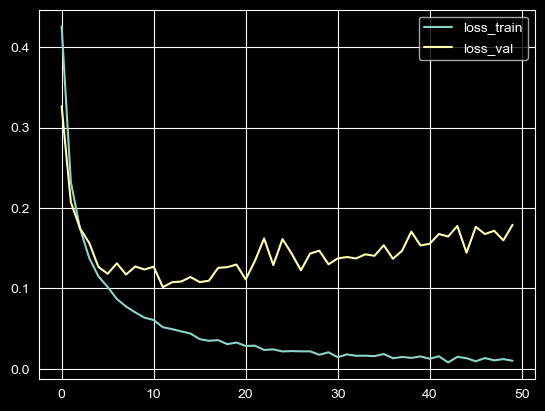

In [33]:
plt.plot(train_loss)
plt.plot(val_loss)
plt.legend(['loss_train', 'loss_val'])
plt.show()

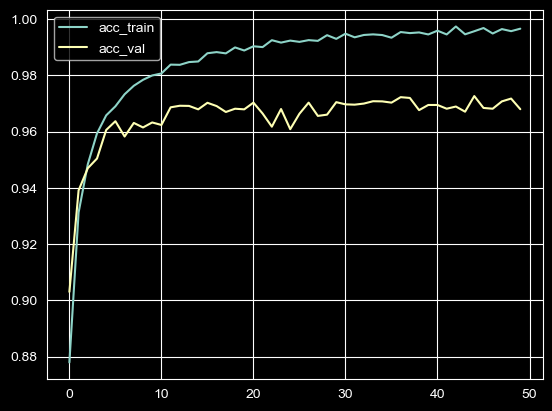

In [34]:
plt.plot(train_acc)
plt.plot(val_acc)
plt.legend(['acc_train', 'acc_val'])
plt.show()

# Задача регрессии

## Создание датасета

In [4]:
class DataSetReg(Dataset):
    def __init__(self, path, transform=None):
        self.path = path
        self.transform = transform

        self.list_name_file = os.listdir(path)
        if 'coords.json' in self.list_name_file:
            self.list_name_file.remove('coords.json')

        self.len_dataset = len(self.list_name_file)

        with open(os.path.join(self.path, 'coords.json'), 'r') as fl:
            self.dict_coords = json.load(fl)

    def __len__(self):
        return self.len_dataset

    def __getitem__(self, index):
        name_file = self.list_name_file[index]
        path_img = os.path.join(self.path, name_file)

        img = np.array(Image.open(path_img))
        coord = np.array(self.dict_coords[name_file])

        if self.transform is not None:
            img = self.transform(img)

        return img, coord

In [5]:
# Преобразования для изображения
transform = v2.Compose(
    [
        v2.ToImage(),
        v2.ToDtype(torch.float32, scale=True),
        v2.Normalize(mean=(0.5,), std=(0.5,))
    ]
)

In [6]:
dataset = DataSetReg('/drive/MyDrive/Colab_Notebooks/content/dataset/', transform=transform) if 'google.colab' in sys.modules \
    else DataSetReg('/Users/SashaCurry/PyCharmMiscProject/content/dataset/', transform=transform)

In [7]:
train_set, val_set, test_set = random_split(dataset, [0.7, 0.1, 0.2])

In [8]:
# Создание загрузчиков
train_loader = DataLoader(train_set, batch_size=16, shuffle=True)
val_loader = DataLoader(val_set, batch_size=16, shuffle=False)
test_loader = DataLoader(test_set, batch_size=16, shuffle=False)

## Создание модели

In [9]:
class MyModel(nn.Module):
    def __init__(self, input, output):
        super().__init__()
        self.layer_1 = nn.Linear(input, 128)
        self.layer_2 = nn.Linear(128, output)
        self.activation = nn.ReLU()

    def forward(self, x):
        x = self.layer_1(x)
        x = self.activation(x)
        out = self.layer_2(x)
        return out


model = MyModel(64*64, 2).to(device)

In [10]:
# Проверяем правильность модели
input = torch.rand([16, 64*64], dtype=torch.float32).to(device)

out = model(input)
print(out.shape)

torch.Size([16, 2])


In [11]:
loss_model = nn.MSELoss()
opt = torch.optim.Adam(model.parameters(), lr=0.001)

## Тренировка модели

In [12]:
train_loss = []
train_acc = []
val_loss = []
val_acc = []

In [13]:
EPOCHS = 50

# Цикл обучения
for epoch in range(EPOCHS):
    # Тренировка модели
    running_train_loss = []
    mean_train_loss = 0
    train_loop = tqdm(train_loader, leave=False) # создание progress bar
    true_answer = 0

    model.train()
    for x, targets in train_loop:
        # Данные
        # (batch_size, 1, 64, 64) -> (batch_size, 64*64)
        x = x.reshape(-1, 64*64).to(device)
        targets = targets.to(torch.float32).to(device)

        # Прямой проход + расчет ошибки модели
        pred = model(x)
        loss = loss_model(pred, targets)

        # Обратный проход
        opt.zero_grad()
        loss.backward()
        # Шаг оптимизации
        opt.step()

        running_train_loss.append(loss.item())
        mean_train_loss = sum(running_train_loss) / len(running_train_loss)

        true_answer += (torch.round(pred) == targets).all(dim=1).sum().item()

        train_loop.set_description(f'Epoch [{epoch+1}/{EPOCHS}], train_loss={mean_train_loss:.4f}')

    # Расчет значения метрики
    running_train_acc = true_answer / len(train_set)

    # Сохранение значения функции потерь и метрики
    train_loss.append(mean_train_loss)
    train_acc.append(running_train_acc)

    # Проверка модели (валидация)
    model.eval()
    with torch.no_grad():
        running_val_loss = []
        true_answer = 0
        for x, targets in val_loader:
            # Данные
            # (batch_size, 1, 64, 64) -> (batch_size, 64*64)
            x = x.reshape(-1, 64*64).to(device)
            targets = targets.to(torch.float32).to(device)

            # Прямой проход + расчет ошибки модели
            pred = model(x)
            loss = loss_model(pred, targets)

            running_val_loss.append(loss.item())
            mean_val_loss = sum(running_val_loss) / len(running_val_loss)

            true_answer += (torch.round(pred) == targets).all(dim=1).sum().item()

        # Расчет значения метрики
        running_val_acc = true_answer / len(val_set)

        # Сохранение значения функции потерь и метрики
        val_loss.append(mean_val_loss)
        val_acc.append(running_val_acc)

        print(f'Epoch [{epoch+1}/{EPOCHS}]: train_loss={mean_train_loss:.4f}, train_acc={running_train_acc:.4f}, val_loss={mean_val_loss:.4f}, val_acc={running_val_acc:.4f}')

Epoch [1/50]: train_loss=1.6400, train_acc=0.6357, val_loss=0.1753, val_acc=0.5336


Epoch [2/50]: train_loss=0.1336, train_acc=0.6957, val_loss=0.0684, val_acc=0.8901


Epoch [3/50]: train_loss=0.1164, train_acc=0.7473, val_loss=0.0979, val_acc=0.7861


Epoch [4/50]: train_loss=0.0996, train_acc=0.7956, val_loss=0.0962, val_acc=0.8081


Epoch [5/50]: train_loss=0.0903, train_acc=0.8264, val_loss=0.0981, val_acc=0.7976


...

Epoch [46/50]: train_loss=0.0418, train_acc=0.9673, val_loss=0.0387, val_acc=0.9739


Epoch [47/50]: train_loss=0.0405, train_acc=0.9698, val_loss=0.0319, val_acc=0.9839


Epoch [48/50]: train_loss=0.0397, train_acc=0.9716, val_loss=0.0445, val_acc=0.9589


Epoch [49/50]: train_loss=0.0397, train_acc=0.9721, val_loss=0.0371, val_acc=0.9746


Epoch [50/50]: train_loss=0.0399, train_acc=0.9709, val_loss=0.0420, val_acc=0.9644


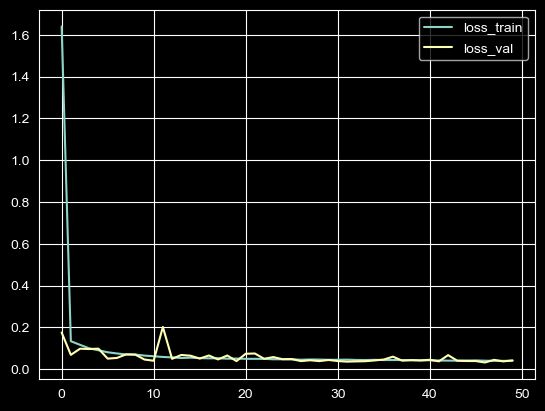

In [14]:
plt.plot(train_loss)
plt.plot(val_loss)
plt.legend(['loss_train', 'loss_val'])
plt.show()

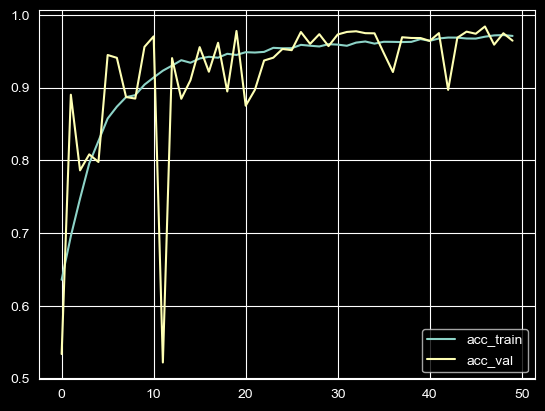

In [15]:
plt.plot(train_acc)
plt.plot(val_acc)
plt.legend(['acc_train', 'acc_val'])
plt.show()